# 7. Landmark detection

Six anatomical points are found directly on the CTA with a 3D U-Net: the internal and external carotid bifurcation on each side, and the first bifurcation of each middle cerebral artery. They anchor the per-vessel analysis and give the start and end points of the individual centerlines.

This runs the model on the fixture CTA (about a minute on a GPU) and then traces two centerlines between landmarks.

In [1]:
import numpy as np, nibabel as nib, matplotlib.pyplot as plt
from arterial_nb import *
from arterial.io.load_and_save_operations import load_json
from arterial.landmark_detection.landmark_detector import LandmarkDetector
from arterial.landmark_detection import utils as lm_utils

cta = nib.load(fixture("cta.nii.gz")); cta_array = np.asarray(cta.dataobj)
detector = LandmarkDetector(case("landmarks"), MODE, fixture("cta.nii.gz"), segmentation_nifti_path=fixture("segmentation.nii.gz"))


Arterial framework for automated characterization of vascular tortuosity.
Copyright 2022-2026 Vall d'Hebron Research Institute (VHIR) and Universitat de Barcelona (UB), Barcelona, Spain.
Code licensed under the PolyForm Noncommercial License 1.0.0. Noncommercial use only.



/home/perecanals/miniconda3/envs/arterial_env_test/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Preprocessing

The CTA is resampled to a fixed grid of 0.8 mm voxels and intensities are rescaled to 0..1. When a segmentation is available it becomes a second input channel, which is the model the pipeline prefers.

preprocessing to the model grid: 2.7 s
model input (1, 2, 480, 320, 320) (batch, channels, D, H, W) at [0.8 0.8 0.8] mm; values in [0.00, 1.00]


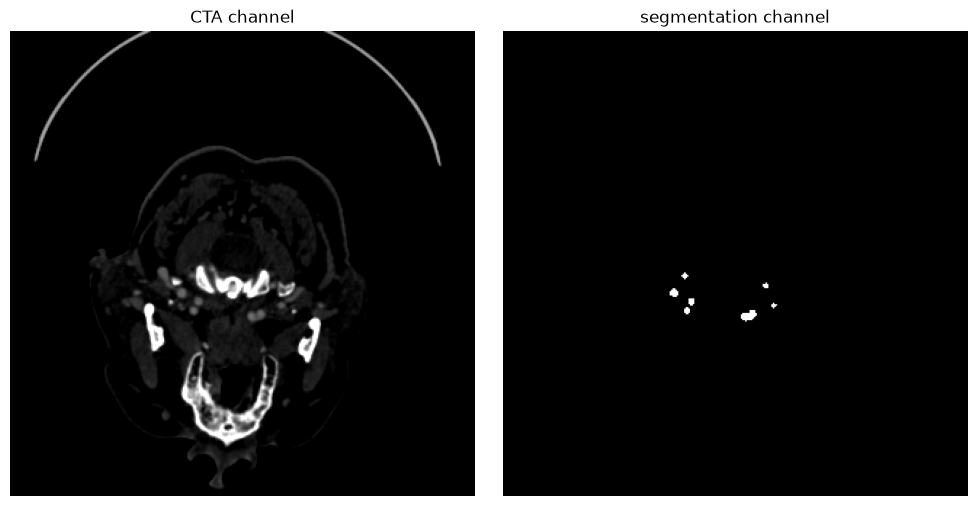

In [2]:
with timed("preprocessing to the model grid"):
    model_input, model_affine = lm_utils.preprocess_for_landmark_detection(cta_array, cta.affine, np.asarray(nib.load(fixture("segmentation.nii.gz")).dataobj))
print("model input", tuple(model_input.shape), "(batch, channels, D, H, W) at", np.round(np.abs(np.diag(model_affine)[:3]), 2), "mm; values in",
      f"[{float(model_input.min()):.2f}, {float(model_input.max()):.2f}]")
channels = model_input[0].cpu().numpy()
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (name, channel) in zip(axes, [("CTA channel", channels[0]), ("segmentation channel", channels[1])]):
    ax.imshow(channel[channel.shape[0] // 2].T, cmap="gray", origin="lower"); ax.set_title(name); ax.axis("off")
plt.tight_layout()

## Detection

The model outputs one probability map per landmark. Each map is thresholded, cleaned, and reduced to the centre of its largest blob. A plausibility check then compares the distance from each carotid bifurcation to its MCA against training statistics; if one side is implausible and the other is fine, the good side is mirrored across the midline to replace it.

In [3]:
with timed("landmark detection (2-channel model + refinement)"), quiet():
    landmarks = detector.detect_landmarks_on_cta(return_mask=True, save=True, use_segmentation_model=True, refine_with_segmentation=True)
table([[name, *np.round(np.asarray(coords), 1)] for name, coords in landmarks.items()], columns=["landmark", "R", "A", "S"])

landmark detection (2-channel model + refinement): 59.8 s


,landmark,R,A,S
0,l-tica,-4.1,198.0,198.6
1,r-tica,25.2,194.8,197.8
2,l-eica,-8.4,179.0,115.4
3,r-eica,31.0,171.1,116.1
4,r-mca,42.1,203.5,195.8
5,l-mca,-16.6,204.0,194.2


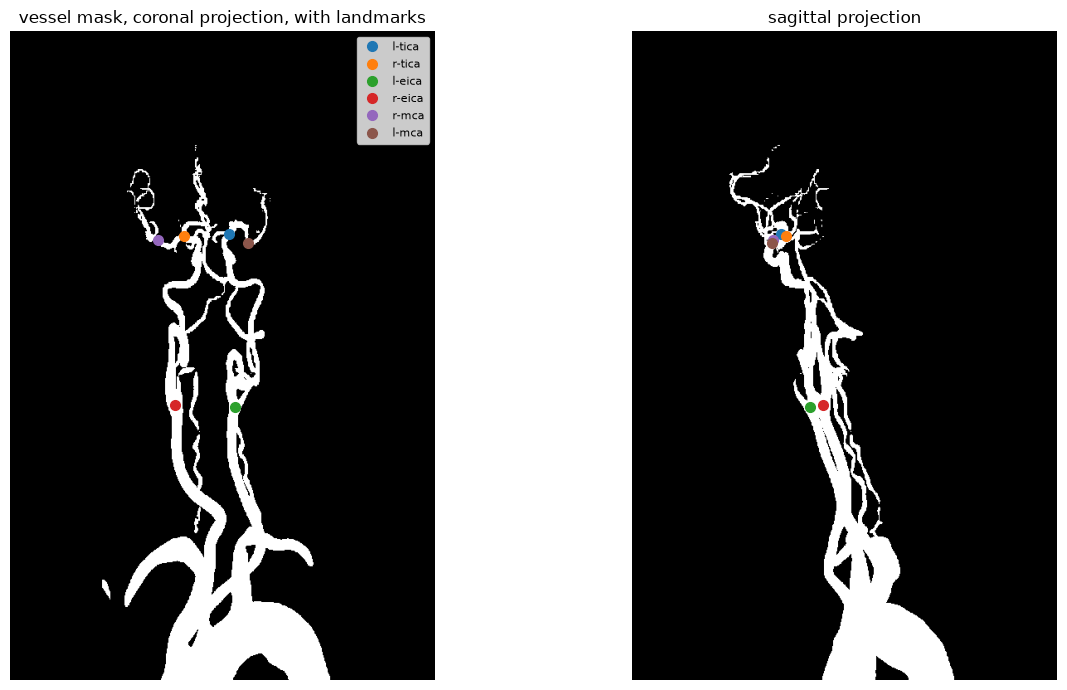

In [4]:
def ras_to_voxel(coords):
    return np.round(np.linalg.inv(cta.affine) @ np.append(coords, 1))[:3].astype(int)

seg_array = np.asarray(nib.load(fixture("segmentation.nii.gz")).dataobj)
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(seg_array.max(axis=1).T, cmap="gray", origin="lower"); axes[0].set_title("vessel mask, coronal projection, with landmarks")
axes[1].imshow(seg_array.max(axis=0).T, cmap="gray", origin="lower"); axes[1].set_title("sagittal projection")
for name, coords in landmarks.items():
    i, j, k = ras_to_voxel(coords)
    axes[0].plot(i, k, "o", markersize=7, label=name); axes[1].plot(j, k, "o", markersize=7)
axes[0].legend(fontsize=8); [ax.axis("off") for ax in axes]; plt.tight_layout()

## The mirror correction, on purpose

Take the detected points, push one MCA far away, and run the correction alone to see it act.

In [5]:
order = ["l-tica", "r-tica", "l-eica", "r-eica", "r-mca", "l-mca"]
points = np.array([landmarks[n] for n in order], dtype=float)
broken = points.copy(); broken[5] += [0, 0, 80]   # l-mca 80 mm too high
fixed, log = lm_utils._apply_mca_mirror_correction(broken.copy())
table([[n, *np.round(points[i], 1), *np.round(broken[i], 1), *np.round(fixed[i], 1)] for i, n in enumerate(order)],
      columns=["landmark", "R", "A", "S", "R (broken)", "A", "S", "R (fixed)", "A", "S"])

,landmark,R,A,S,R (broken),A,S,R (fixed),A,S
0,l-tica,-4.1,198.0,198.6,-4.1,198.0,198.6,-4.1,198.0,198.6
1,r-tica,25.2,194.8,197.8,25.2,194.8,197.8,25.2,194.8,197.8
2,l-eica,-8.4,179.0,115.4,-8.4,179.0,115.4,-8.4,179.0,115.4
3,r-eica,31.0,171.1,116.1,31.0,171.1,116.1,31.0,171.1,116.1
4,r-mca,42.1,203.5,195.8,42.1,203.5,195.8,42.1,203.5,195.8
5,l-mca,-16.6,204.0,194.2,-16.6,204.0,274.2,-20.2,203.5,195.8


In [6]:
print("correction log:", log)

correction log: {'l-mca': {'displacement_mm': 78.5}}


## Refinement with the segmentation

The centroid of a blob is not always on the vessel. When a segmentation exists, each landmark is snapped onto the nearest bifurcation of the vessel skeleton within a few millimetres. The detector did this already above; here it is shown alone with the stats it reports.

In [7]:
segmentation = nib.load(fixture("segmentation.nii.gz"))
with timed("refinement"), quiet():
    refined, stats = lm_utils.refine_landmarks_with_segmentation(landmarks, np.asarray(segmentation.dataobj), segmentation.affine, search_radius_mm=5.0)
table([[n, round(float(np.linalg.norm(np.asarray(refined[n]) - np.asarray(landmarks[n]))), 2)] for n in landmarks], columns=["landmark", "moved (mm)"])

refinement: 43.8 s


,landmark,moved (mm)
0,l-tica,0.0
1,r-tica,0.0
2,l-eica,0.0
3,r-eica,0.0
4,r-mca,0.0
5,l-mca,0.0


## Centerlines between landmarks

With two landmarks in hand, VMTK can trace the single centerline that joins them, for example the internal carotid from its origin to the top of the carotid siphon. These per-vessel centerlines feed the geometry export of notebook 8.

individual centerlines (includes surface preprocessing): 29.0 s


2026-09-11 17:30:21.411 ( 142.756s) [        8ABD5740]vtkvmtkSteepestDescentL:240   WARN| vtkvmtkSteepestDescentLineTracer (0x644f98091070): Degenerate descent detected. Target not reached.


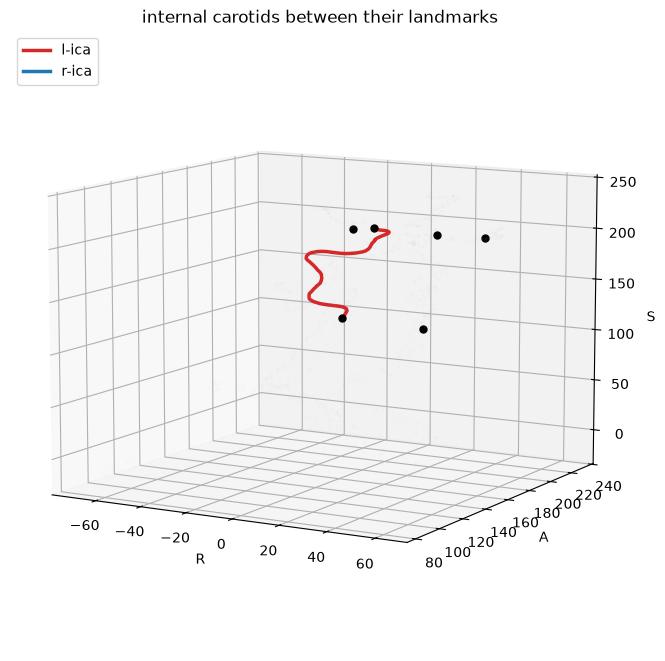

In [8]:
from arterial.centerline_extraction.centerline_extractor import CenterlineExtractor
extractor = CenterlineExtractor(case("landmarks"), MODE, fixture("segmentation.nii.gz"), fast_segmentation=False)
with timed("individual centerlines (includes surface preprocessing)"), quiet():
    for centerline_id, (start, end) in {"l-ica": ("l-eica", "l-tica"), "r-ica": ("r-eica", "r-tica")}.items():
        extractor.extract_centerline_between_endpoints(landmarks[start], landmarks[end], centerline_id=centerline_id)
fig = plt.figure(figsize=(8, 9)); ax = fig.add_subplot(111, projection="3d")
plot_polydata([extractor.segmentation_model] + extractor.individual_centerlines_list, colors=["lightgray", "C3", "C0"], labels=[None, "l-ica", "r-ica"], ax=ax, linewidth=2.5, title="internal carotids between their landmarks")
for coords in landmarks.values():
    ax.scatter(*coords, color="black", s=25)

## Notes

- Without a segmentation the one-channel model is used and refinement is skipped; the pipeline prints which one it took.
- A landmark reported at exactly (0, 0, 0) means its class was not found in the image.
- The saved mask (`landmarks_mask.nii.gz`) is on the model grid resampled back to the CTA; check it against the CTA before trusting it for anything but a visual.